Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjuntos de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [2]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv("./data/Autos_data.txt", 
                 sep= r'\s+',
                 names = column_names,
                 usecols=range(len(column_names)))

df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    object 
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [4]:
df["Horsepower"].value_counts()

Horsepower
150.0    22
90.00    20
88.00    19
110.0    18
100.0    17
         ..
77.00     1
132.0     1
64.00     1
116.0     1
82.00     1
Name: count, Length: 94, dtype: int64

In [5]:
def ObservarFrecuenciasColumna (nomCol):
    with pd.option_context('display.max_rows', None):
     print(df[nomCol].value_counts().sort_index())

In [6]:
for c in column_names:
    print("Frecuencias para la columna ", c)
    ObservarFrecuenciasColumna(c)

Frecuencias para la columna  MPG
MPG
9.0      1
10.0     2
11.0     4
12.0     6
13.0    20
14.0    19
14.5     1
15.0    16
15.5     5
16.0    13
16.2     1
16.5     3
16.9     1
17.0     7
17.5     5
17.6     2
17.7     1
18.0    17
18.1     2
18.2     1
18.5     3
18.6     1
19.0    12
19.1     1
19.2     3
19.4     2
19.8     1
19.9     1
20.0     9
20.2     4
20.3     1
20.5     3
20.6     2
20.8     1
21.0     8
21.1     1
21.5     3
21.6     1
22.0    10
22.3     1
22.4     1
22.5     1
23.0    10
23.2     1
23.5     1
23.6     1
23.7     1
23.8     1
23.9     2
24.0    11
24.2     1
24.3     1
24.5     2
25.0    11
25.1     1
25.4     2
25.5     2
25.8     1
26.0    14
26.4     1
26.5     1
26.6     2
26.8     1
27.0     9
27.2     3
27.4     1
27.5     1
27.9     1
28.0    10
28.1     1
28.4     1
28.8     1
29.0     8
29.5     2
29.8     2
29.9     1
30.0     7
30.5     2
30.7     1
30.9     1
31.0     7
31.3     1
31.5     2
31.6     1
31.8     1
31.9     1
32.0     6
32.1  

In [7]:
df[df["Horsepower"] == '?']  

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
32,25.0,4,98.0,?,2046.0,19.0,71,1
126,21.0,6,200.0,?,2875.0,17.0,74,1
330,40.9,4,85.0,?,1835.0,17.3,80,2
336,23.6,4,140.0,?,2905.0,14.3,80,1
354,34.5,4,100.0,?,2320.0,15.8,81,2
374,23.0,4,151.0,?,3035.0,20.5,82,1


In [8]:
df = df[df["Horsepower"] != '?']

df["Horsepower"] = df["Horsepower"].astype(float)
df = df.reset_index(drop=True)


In [9]:
df["Horsepower"].dtype

dtype('float64')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 24.6 KB


### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*

¿Por qué no codificar a lo loco?: No deberías pasar a One-Hot (vectorizar) una variable sin analizarla antes. A lo mejor te interesa mantener el orden (codificación ordinal) o hacer transformaciones basadas en la relación con el "target" (lo que quieres predecir, como el consumo MPG). Esas decisiones suelen tomarse tras ver los datos del set de entrenamiento (train) para no "contaminar" el modelo con información del futuro.

La excepción del sentido común: Si tienes claro cristalino que vas a vectorizar (como en este caso, donde USA, Europa y Japón son categorías cerradas), no pasa nada por hacerlo antes de dividir los datos en train y test.

El seguro de vida (Unknown): Siempre es buena idea tener una categoría "Comodín" o Unknown. ¿Por qué? Porque si mañana entra un coche fabricado en Corea y tu modelo solo conoce USA, Europa y Japón, el código petará o dará un error. Si tienes un hueco para "otros", el modelo será más robusto ante datos nuevos.


In [11]:
origenes = {
    1 : 'USA',
    2 : 'Europa',
    3 : 'Japón'
}

df['Origin'] = df['Origin'].map(origenes)


In [12]:
# Hacemos el One-Hot Encoding
# 'prefix' añade un prefijo a las nuevas columnas para saber de dónde vienen
# 'dtype=int' para que nos devuelva 0 y 1 en lugar de True/False
df = pd.get_dummies(
    df,
    columns = ['Origin'],
    prefix = 'Origin',
    dtype = int
)

In [13]:
df.sample(10)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_Europa,Origin_Japón,Origin_USA
174,19.0,6,232.0,90.0,3211.0,17.0,75,0,0,1
28,9.0,8,304.0,193.0,4732.0,18.5,70,0,0,1
367,27.0,4,151.0,90.0,2735.0,18.0,82,0,0,1
337,23.5,6,173.0,110.0,2725.0,12.6,81,0,0,1
35,19.0,6,250.0,88.0,3302.0,15.5,71,0,0,1
170,25.0,4,90.0,71.0,2223.0,16.5,75,1,0,0
84,13.0,8,350.0,175.0,4100.0,13.0,73,0,0,1
224,20.5,6,231.0,105.0,3425.0,16.9,77,0,0,1
25,10.0,8,360.0,215.0,4615.0,14.0,70,0,0,1
292,34.1,4,86.0,65.0,1975.0,15.2,79,0,1,0


### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [14]:
from sklearn.model_selection import train_test_split

target = 'MPG'

X = df.drop(columns = target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

In [15]:
train_dataset = X_train.copy()
train_dataset[target] = y_train

test_dataset = X_test.copy()
test_dataset[target] = y_test

# Verificamos el tamaño de los nuevos datasets
print(f"Dataset de entrenamiento: {train_dataset.shape}")
print(f"Dataset de pruebas: {test_dataset.shape}")

Dataset de entrenamiento: (313, 10)
Dataset de pruebas: (79, 10)


### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

array([[<Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>,
        <Axes: title={'center': 'Horsepower'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>,
        <Axes: title={'center': 'Model Year'}>],
       [<Axes: title={'center': 'Origin_Europa'}>,
        <Axes: title={'center': 'Origin_Japón'}>,
        <Axes: title={'center': 'Origin_USA'}>],
       [<Axes: title={'center': 'MPG'}>, <Axes: >, <Axes: >]],
      dtype=object)

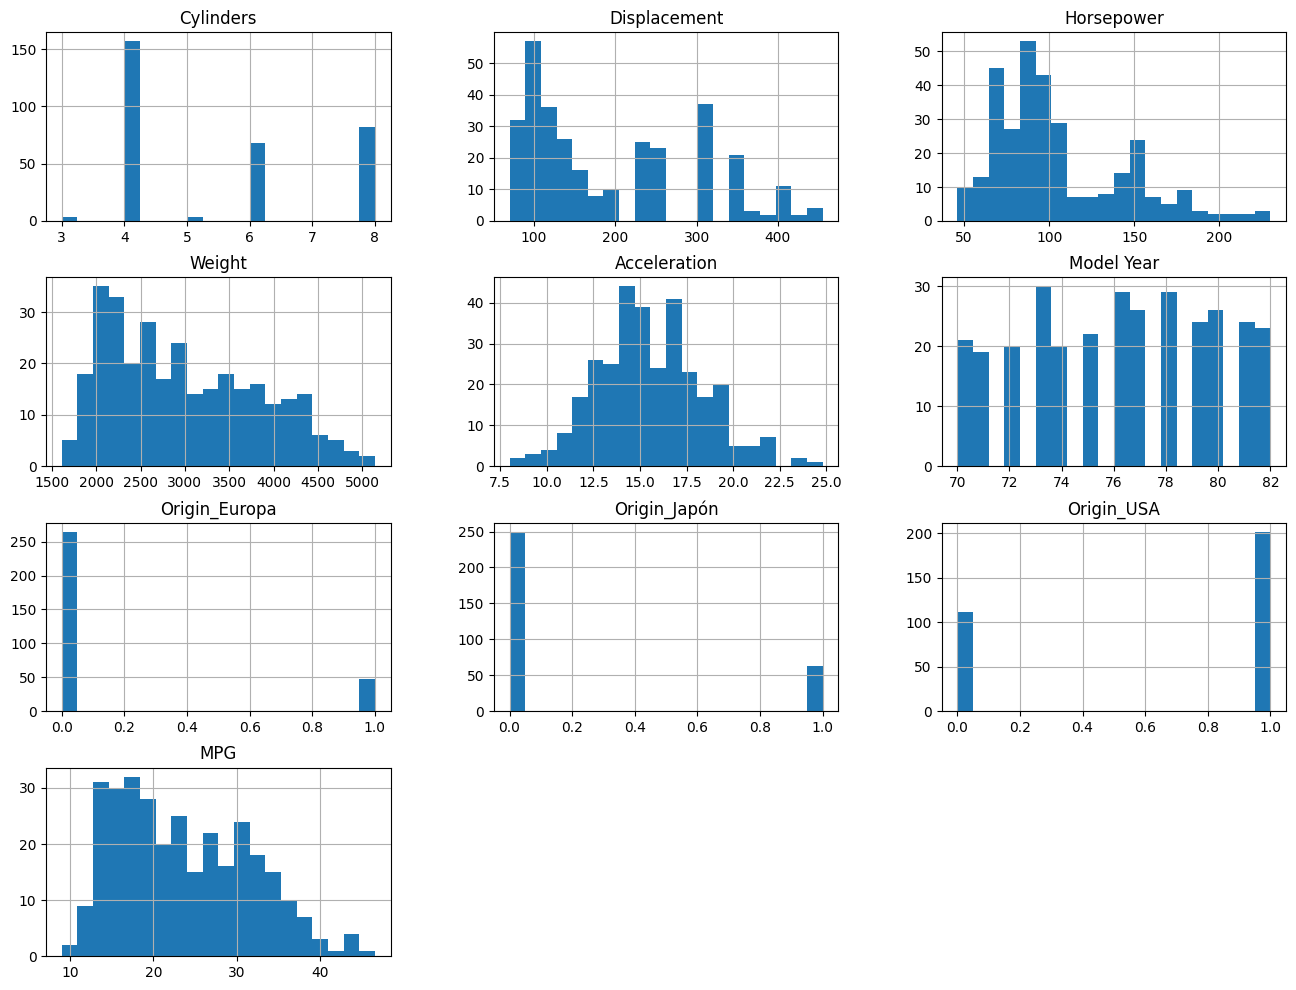

In [16]:
#Distribución marginal
train_dataset.hist(
    figsize=(16,12),
    bins = 20
)

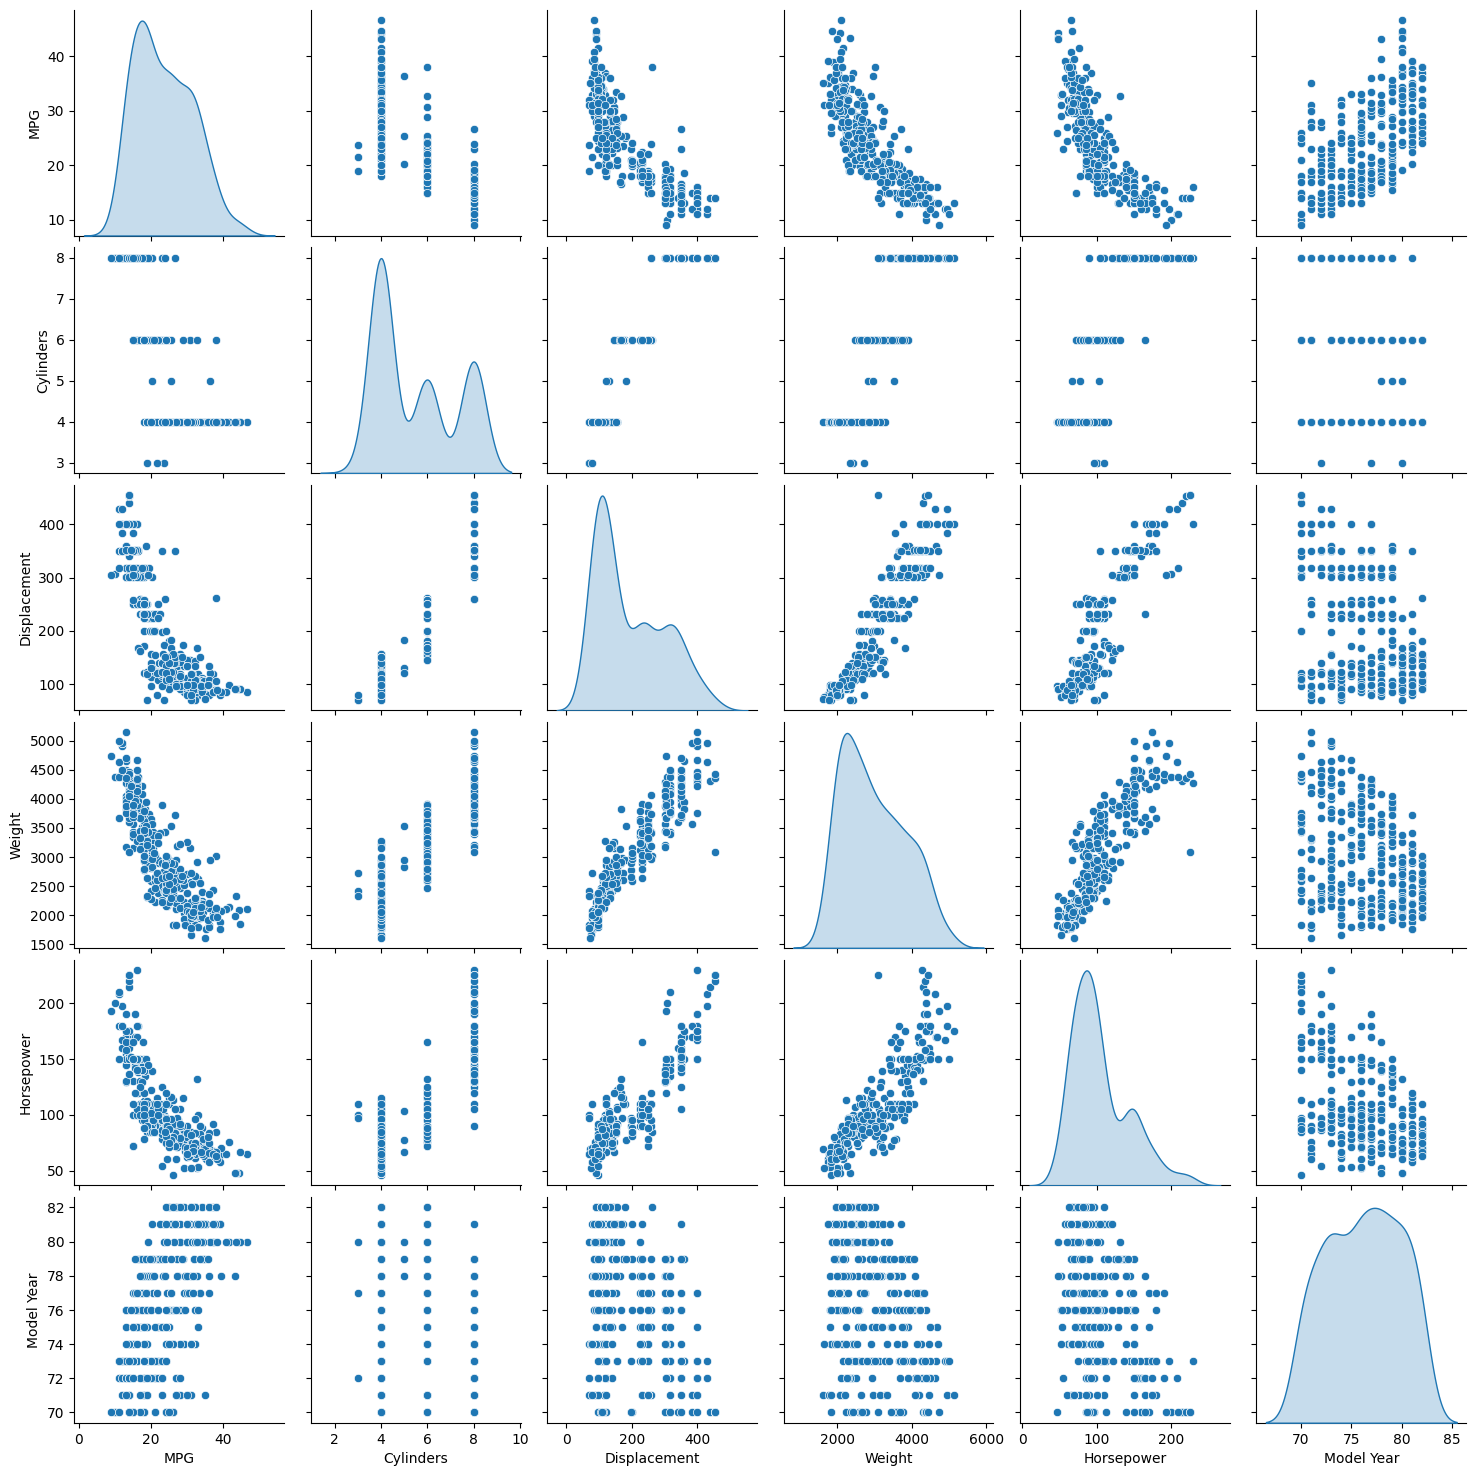

In [17]:
#Distribución conjunta
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las columnas numéricas más relevantes para no saturar el gráfico
cols_telemetria = ['MPG', 'Cylinders', 'Displacement', 'Weight', 'Horsepower', 'Model Year']

# Creamos el pairplot
# diag_kind='kde': En la diagonal, en lugar de barras, te pone una curva de densidad (más suave)
sns.pairplot(train_dataset[cols_telemetria], diag_kind='kde')
plt.show()

### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns = train_dataset.columns.drop(target),
    index = X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns = test_dataset.columns.drop(target),
    index = X_test.index
)


In [19]:
X_train_scaled_df.head()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_Europa,Origin_Japón,Origin_USA
258,0.304862,0.284578,0.141429,0.754803,1.121759,0.494528,-0.425596,-0.501996,0.741286
182,-0.873184,-0.535880,-0.329499,-0.493129,-0.228940,-0.057298,-0.425596,-0.501996,0.741286
172,0.304862,-0.236655,-0.198685,-0.002530,-0.371118,-0.333211,-0.425596,-0.501996,0.741286
63,1.482907,1.182255,1.187934,1.368052,-0.726565,-1.160950,-0.425596,-0.501996,0.741286
340,-0.873184,-1.057113,-1.062052,-1.323099,0.304231,1.322266,-0.425596,-0.501996,0.741286


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [20]:
# 1. Calculamos el número de features de entrada
# (Cilindros, Peso, Año, Origen_USA, etc...)
n_features = X_train_scaled.shape[1]

n_features

9

In [21]:
# 2. Definimos la potencia (neuronas)
# Siguiendo tu nota: features x 3 aprox. Si tienes ~9 features, 32 es un buen número "redondo" (potencia de 2).
n_neuronas = 32

In [22]:
# 3. Construimos el chasis (Modelo Secuencial)
model = keras.Sequential([
    # 1ª Capa Oculta + Entrada
    # input_shape: La "boca de admisión" del modelo, debe coincidir con tus columnas.
    layers.Dense(
        n_neuronas, 
        activation='relu', 
        input_shape=[n_features]
        ),
    
    # 2ª Capa Oculta (Arquitectura Prisma: mantenemos el número de neuronas)
    layers.Dense(
        n_neuronas, 
        activation='relu'
        ),
    
    # Capa de Salida
    # Una única neurona sin función de activación (lineal) porque queremos predecir un valor continuo (MPG).
    # Si pusiéramos 'sigmoid' o 'relu' aquí, estaríamos limitando la salida artificialmente.
    layers.Dense(1)
])

h:\RepoBootcamp\RepoEjercicios\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# 4. Ajustamos la electrónica (Compilar)
# El optimizador RMSprop es un clásico robusto para regresión.
optimizer = tf.keras.optimizers.RMSprop(0.001)

model.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae', 'mse'])

### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [24]:
# 5. Pasamos la ITV (Ver estructura)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [25]:
# Primero aislamos la variable objetivo (el consumo) del set de entrenamiento
y_train = train_dataset['MPG']

In [26]:
# ¡Arrancamos motores!
history = model.fit(
    X_train_scaled,       # Las características (input)
    y_train,              # La etiqueta real (target)
    epochs=1000,          # Número de vueltas
    validation_split=0.2, # El 20% de los datos se reserva para validar en cada vuelta (no entrena con ellos)
    verbose=0             # Muestra el progreso (pon 0 si no quieres que te imprima 1000 líneas)
)

### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

In [27]:
# 1. Convertimos el historial a un DataFrame para manejarlo fácil
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

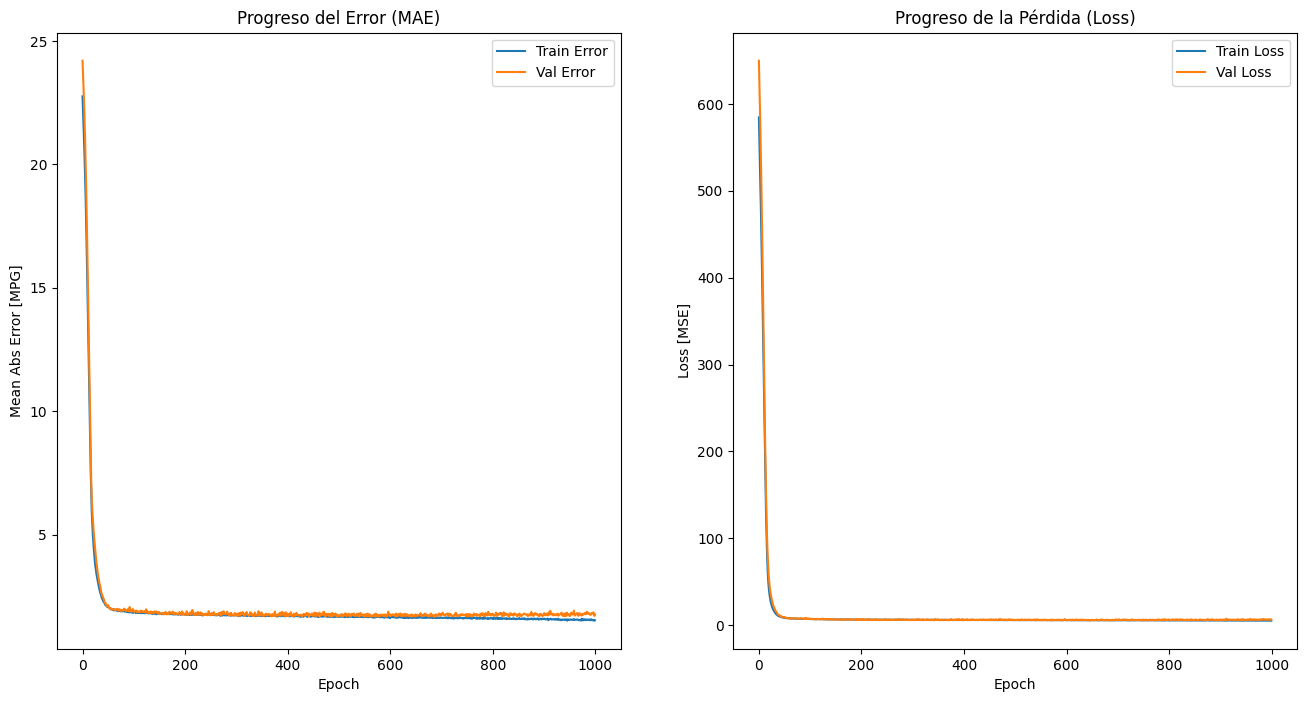

In [30]:
# 2. Preparamos el "Canvas" (el lienzo) con dos gráficas una al lado de la otra
plt.figure(figsize=(16, 8))

# --- GRÁFICA 1: Evolución del Error (MAE) ---
plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(hist['epoch'], hist['mae'], label='Train Error')
plt.plot(hist['epoch'], hist['val_mae'], label='Val Error')
plt.legend()
plt.title('Progreso del Error (MAE)')

# --- GRÁFICA 2: Evolución de la Pérdida (Loss - MSE) ---
plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Loss [MSE]')
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Val Loss')
plt.legend()
plt.title('Progreso de la Pérdida (Loss)')

plt.show()

### Ejercicio 11

Comenta las gráficas anteriores.

Ambas líneas (azul y naranja) caen en picado durante las primeras 100 "vueltas" (epochs). Eso es excelente. Significa que la red neuronal ha entendido rapidísimo las reglas básicas del juego (cilindrada, peso, etc.).

A partir de la época 150 o 200, la curva se aplana casi por completo.

La línea azul (Train) sigue bajando muy lentamente (el modelo sigue "memorizando" detalles minúsculos de los datos de entrenamiento).

La línea naranja (Validación) se queda estancada, incluso con un poco de ruido (esos dientes de sierra).

El modelo alcanzó su pico de rendimiento hace mucho tiempo.

Si hubiera un overfitting severo, veríamos que la línea naranja empieza a subir descaradamente mientras la azul sigue bajando (formando una boca de cocodrilo). Aquí se mantienen bastante paralelas y cercanas, lo cual indica que el modelo es robusto y generaliza bien.

### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

In [31]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

h:\RepoBootcamp\RepoEjercicios\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
optimizer = tf.keras.optimizers.RMSprop(0.001)
model.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae', 'mse'])

In [34]:
# DEFINIMOS EL CALLBACK
# monitor='val_loss': Vigila el error en el set de validación.
# patience=20: Si en 20 vueltas no mejoras, paras.
early_stop = EarlyStopping(monitor='val_loss', patience=20)

In [35]:
# ENTRENAMOS CON EL CALLBACK
# Mantenemos epochs=1000 como "límite teórico", pero sabemos que parará mucho antes.
history_early = model.fit(
    X_train_scaled,
    y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop] # Aquí es donde entra la magia
)

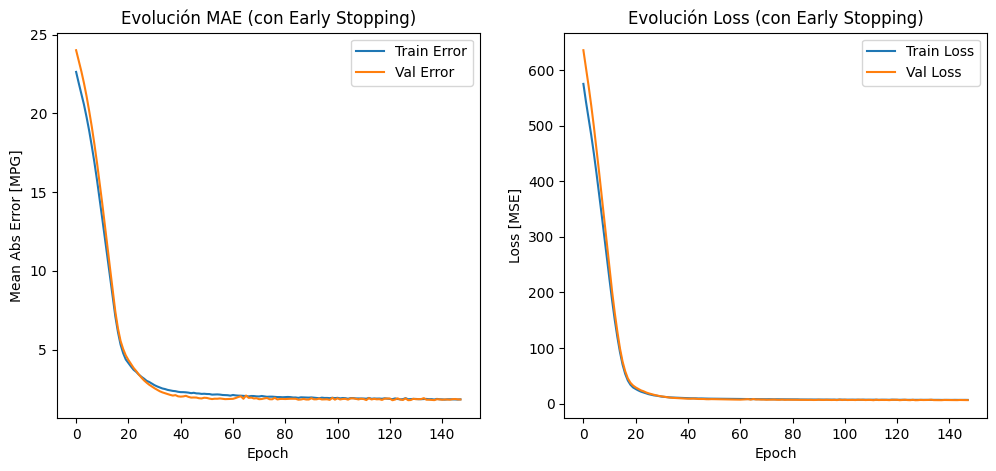

El entrenamiento se detuvo en la época: 148
MAE medio estabilizado en validación: 1.8311 MPG


In [36]:
# VISUALIZACIÓN Y ANÁLISIS
hist = pd.DataFrame(history_early.history)
hist['epoch'] = history_early.epoch

plt.figure(figsize=(12, 5))

# Gráfica MAE
plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(hist['epoch'], hist['mae'], label='Train Error')
plt.plot(hist['epoch'], hist['val_mae'], label='Val Error')
plt.legend()
plt.title('Evolución MAE (con Early Stopping)')

# Gráfica Loss
plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Loss [MSE]')
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Val Loss')
plt.legend()
plt.title('Evolución Loss (con Early Stopping)')

plt.show()

# 6. OBTENCIÓN DEL MAE ESTABILIZADO
# Tomamos el último valor de validación registrado antes de que el árbitro pitara el final.
mae_final = hist['val_mae'].iloc[-1]
print(f"El entrenamiento se detuvo en la época: {len(hist)}")
print(f"MAE medio estabilizado en validación: {mae_final:.4f} MPG")

Interpreta el gráfico

la gráfica se corta alrededor de la epoch 145.

El sistema ha detectado que desde la epoch 125 (aprox) la línea naranja (Val Error) ya no bajaba más.

Gracias a la patience=20, te has ahorrado unas 850 vueltas de "basura". Has conseguido el mismo resultado en un 15% del tiempo. Eficiencia pura.

Líneas pegadas: La línea azul (Train) y la naranja (Validation) van de la mano todo el camino. Incluso se cruzan y tocan al final.

Interpretación: El modelo no está memorizando (si lo hiciera, la azul seguiría bajando y la naranja subiría). Ha entendido la lógica general de los datos. Funciona igual de bien con los coches que conoce (train) que con los que no (validación).

### Ejercicio 13

Veamos cómo de bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice cómo de bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [37]:
# Evaluamos el modelo con el conjunto de test (X_test_scaled) y sus etiquetas reales (y_test)
loss, mae, mse = model.evaluate(X_test_scaled, y_test, verbose=2)

print("\n--- Resultados Finales en Test ---")
print(f"Loss (MSE): {loss:.2f}")
print(f"MAE (Error Medio Absoluto): {mae:.2f} MPG")
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")

3/3 - 0s - 8ms/step - loss: 6.6121 - mae: 1.8876 - mse: 6.6121

--- Resultados Finales en Test ---
Loss (MSE): 6.61
MAE (Error Medio Absoluto): 1.89 MPG
MSE (Error Cuadrático Medio): 6.61


MAE (1.89 MPG): De media, tu modelo se equivoca en menos de 2 millas por galón. Teniendo en cuenta que el consumo medio en este dataset ronda los 23 MPG, tienes un error inferior al 10%. Es un modelo muy fiable para estimar el consumo de un coche clásico.

MSE (6.61) vs MAE (1.89): Aquí hay un detalle interesante de ingeniería.Si haces la raíz cuadrada del MSE ($\sqrt{6.61} \approx 2.57$), obtienes el RMSE.Como el RMSE (2.57) es mayor que el MAE (1.89), esto nos chiva que tienes algunos "outliers": hay un par de coches donde el modelo patina bastante (quizás un error de 5 o 6 MPG), y eso penaliza más al MSE.

### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


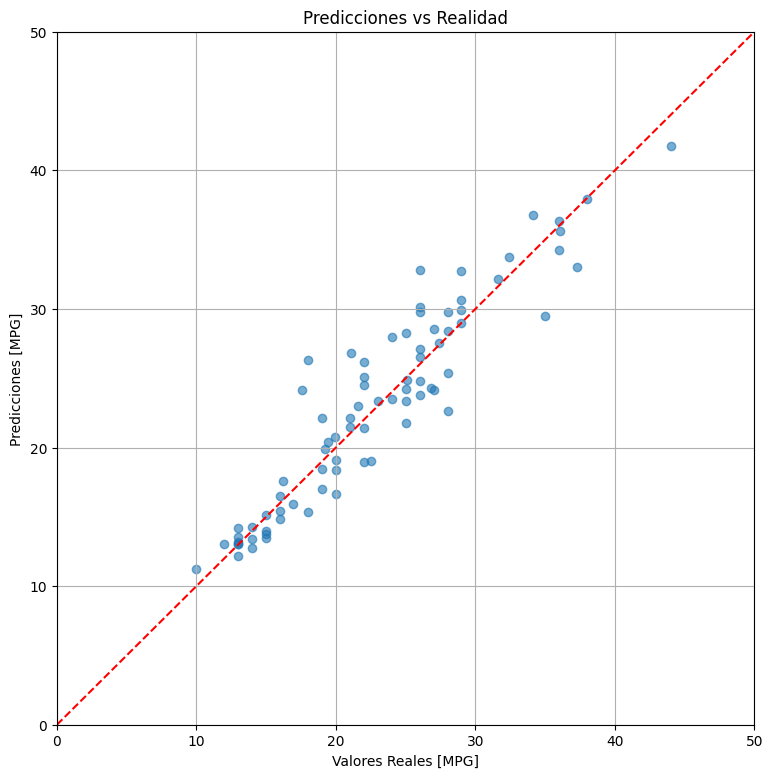

In [39]:
# Hacemos las predicciones con el set de test
test_predictions = model.predict(X_test_scaled).flatten()

plt.figure(figsize=(9, 9))
plt.scatter(y_test, test_predictions, alpha=0.6)
plt.xlabel('Valores Reales [MPG]')
plt.ylabel('Predicciones [MPG]')
plt.title('Predicciones vs Realidad')

# Pintamos la línea diagonal de referencia (la perfección)
# Si un punto cae en la línea roja, la predicción fue exacta.
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, color='red', linestyle='--')

plt.grid(True)
plt.show()